In [6]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tifffile

In [12]:
PROJECT_DIR = Path(
    r"C:\Users\User\Desktop\白血球画像分類"
)

BASE_DIR = PROJECT_DIR / "Stained_Montages"
OUTPUT_DIR = PROJECT_DIR / "processed"

CELL_SIZE = 55
GRID_SIZE = 1650 // CELL_SIZE

print("Grid size:", GRID_SIZE, "x", GRID_SIZE)

Grid size: 30 x 30


In [13]:
def cell_batch(subject, class_name, batch):

    data_dir = BASE_DIR / subject / class_name / batch

    # Find all ch1 montage files
    ch1_files = sorted(data_dir.glob("ch1_*.tif"))

    if len(ch1_files) == 0:
        raise ValueError(f"No channel files found: {data_dir}")

    all_cells = []
    cell_counter = 0

    for ch1_path in ch1_files:

        montage_id = ch1_path.stem.split("_")[-1]

        ch3_path = data_dir / f"ch3_{montage_id}.tif"
        ch5_path = data_dir / f"ch5_{montage_id}.tif"

        if not ch3_path.exists() or not ch5_path.exists():
            raise ValueError(
                f"Missing channel pair for montage {montage_id}: {data_dir}"
            )

        ch1 = tifffile.imread(ch1_path)
        ch3 = tifffile.imread(ch3_path)
        ch5 = tifffile.imread(ch5_path)

        if not (ch1.shape == ch3.shape == ch5.shape):
            raise ValueError(
                f"Channel shapes do not match: "
                f"ch1={ch1.shape}, ch3={ch3.shape}, ch5={ch5.shape}"
            )

        valid_positions = []

        for row in range(GRID_SIZE):
            for col in range(GRID_SIZE):

                y1 = row * CELL_SIZE
                y2 = y1 + CELL_SIZE

                x1 = col * CELL_SIZE
                x2 = x1 + CELL_SIZE

                cell = ch5[y1:y2, x1:x2]

                if np.any(cell != 0):
                    valid_positions.append((row, col))

        print(
            f"{subject} / {class_name} / {batch} / montage {montage_id}: "
            f"{len(valid_positions)} cells"
        )

        # 保存先フォルダ
        save_dir = (
            OUTPUT_DIR
            / subject
            / class_name
            / batch
            / f"montage_{montage_id}"
        )

        save_dir.mkdir(parents=True, exist_ok=True)

        for row, col in valid_positions:

            y1 = row * CELL_SIZE
            y2 = y1 + CELL_SIZE
            x1 = col * CELL_SIZE
            x2 = x1 + CELL_SIZE

            cell_ch1 = ch1[y1:y2, x1:x2]
            cell_ch3 = ch3[y1:y2, x1:x2]
            cell_ch5 = ch5[y1:y2, x1:x2]

            # 保存するファイル名
            ch1_save = save_dir / f"cell_{cell_counter:04d}_ch1.tif"
            ch3_save = save_dir / f"cell_{cell_counter:04d}_ch3.tif"
            ch5_save = save_dir / f"cell_{cell_counter:04d}_ch5.tif"

            # TIFFとしてdiskに保存
            tifffile.imwrite(ch1_save, cell_ch1)
            tifffile.imwrite(ch3_save, cell_ch3)
            tifffile.imwrite(ch5_save, cell_ch5)

            cell_dict = {
                "subject": subject,
                "class_name": class_name,
                "batch": batch,
                "montage_id": montage_id,
                "cell_id": cell_counter,
                "row": row,
                "col": col,
                "ch1_path": str(ch1_save.relative_to(OUTPUT_DIR)),
                "ch3_path": str(ch3_save.relative_to(OUTPUT_DIR)),
                "ch5_path": str(ch5_save.relative_to(OUTPUT_DIR))
            }

            all_cells.append(cell_dict)

            cell_counter += 1

    return all_cells

In [14]:
def batch_processor(subject, class_name):
    class_dir = BASE_DIR / subject / class_name

    batch_dirs = sorted([
        folder.name
        for folder in class_dir.iterdir()
        if folder.is_dir() and folder.name.startswith("batch")
    ])
    print(batch_dirs)
    all_cells = []

    for batch_name in batch_dirs:
        batch_cells = cell_batch(
            subject,
            class_name,
            batch_name
        )

        all_cells.extend(batch_cells)

    return all_cells

In [15]:
def batch_visualiser(cells, channels, titles):

    fig, axes = plt.subplots(
        len(cells),
        len(channels),
        figsize=(9, 3 * len(cells))
    )

    for row_idx, cell in enumerate(cells):

        for col_idx, (channel, title) in enumerate(zip(channels, titles)):

            ax = axes[row_idx, col_idx]

            ax.imshow(cell[channel], cmap="gray")

            if row_idx == 0:
                ax.set_title(title)

            if col_idx == 0:
                ax.set_ylabel(
                    f'{cell["subject"]}\n'
                    f'{cell["class_name"]}\n'
                    f'{cell["batch"]}\n'
                    f'montage={cell["montage_id"]}\n'
                    f'cell={cell["cell_id"]}'
                )

            ax.axis("off")

    plt.tight_layout()
    plt.show()

In [16]:
test_cells = cell_batch(
    "CRF022",
    "B",
    "batch1"
)
print(test_cells[0])

CRF022 / B / batch1 / montage 1: 197 cells
{'subject': 'CRF022', 'class_name': 'B', 'batch': 'batch1', 'montage_id': '1', 'cell_id': 0, 'row': 0, 'col': 0, 'ch1_path': 'CRF022\\B\\batch1\\montage_1\\cell_0000_ch1.tif', 'ch3_path': 'CRF022\\B\\batch1\\montage_1\\cell_0000_ch3.tif', 'ch5_path': 'CRF022\\B\\batch1\\montage_1\\cell_0000_ch5.tif'}


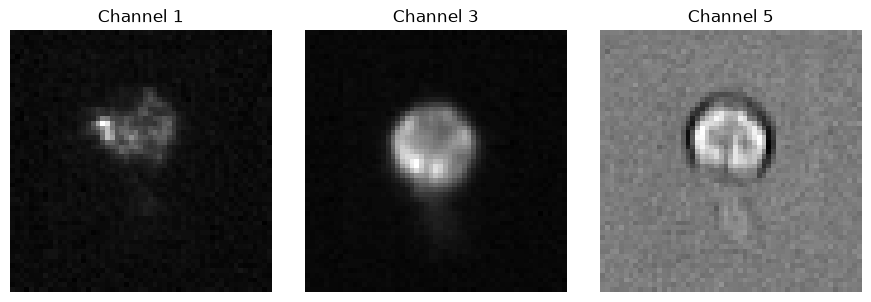

In [17]:
cell = test_cells[0]

ch1 = tifffile.imread(OUTPUT_DIR / cell["ch1_path"])
ch3 = tifffile.imread(OUTPUT_DIR / cell["ch3_path"])
ch5 = tifffile.imread(OUTPUT_DIR / cell["ch5_path"])

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

channels = [ch1, ch3, ch5]
titles = ["Channel 1", "Channel 3", "Channel 5"]

for ax, image, title in zip(axes, channels, titles):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [18]:
CLASS_NAMES = [
    "B",
    "T",
    "eosinophil",
    "monocyte",
    "neutrophil"
]
subjects = sorted([
    folder.name
    for folder in BASE_DIR.iterdir()
    if folder.is_dir()
])

print("Subjects:")
for subject in subjects:
    print(subject)

print("Number of subjects:", len(subjects))

Subjects:
CRF022
CRF034
CRF041
CRF049
CRF066
CRF074
CRF101_2014
CRF101_2015
CRF102
CRF130
CRF132
CRF186
CRF59
Number of subjects: 13


In [19]:
all_metadata = []

for subject in subjects:

    print(f"\n===== {subject} =====")

    for class_name in CLASS_NAMES:

        class_dir = BASE_DIR / subject / class_name

        # クラスフォルダが存在するか確認
        if not class_dir.exists():
            print(f"Skipped: {subject} / {class_name} does not exist")
            continue

        print(f"\nProcessing: {subject} / {class_name}")

        class_cells = batch_processor(
            subject,
            class_name
        )

        all_metadata.extend(class_cells)


===== CRF022 =====

Processing: CRF022 / B
['batch1', 'batch2', 'batch3']
CRF022 / B / batch1 / montage 1: 197 cells
CRF022 / B / batch2 / montage 1: 193 cells
CRF022 / B / batch3 / montage 1: 143 cells

Processing: CRF022 / T
['batch1', 'batch2']
CRF022 / T / batch1 / montage 1: 900 cells
CRF022 / T / batch1 / montage 2: 1 cells
CRF022 / T / batch2 / montage 1: 900 cells
CRF022 / T / batch2 / montage 2: 15 cells

Processing: CRF022 / eosinophil
['batch1', 'batch2']
CRF022 / eosinophil / batch1 / montage 1: 270 cells
CRF022 / eosinophil / batch2 / montage 1: 1 cells

Processing: CRF022 / monocyte
['batch1']
CRF022 / monocyte / batch1 / montage 1: 346 cells

Processing: CRF022 / neutrophil
['batch1', 'batch2']
CRF022 / neutrophil / batch1 / montage 1: 813 cells
CRF022 / neutrophil / batch2 / montage 1: 880 cells

===== CRF034 =====

Processing: CRF034 / B
['batch1', 'batch2']
CRF034 / B / batch1 / montage 1: 73 cells
CRF034 / B / batch2 / montage 1: 79 cells

Processing: CRF034 / T
['b

In [20]:
print("Total number of cells:", len(all_metadata))

Total number of cells: 100105


In [22]:
import pandas as pd
metadata_df = pd.DataFrame(all_metadata)
metadata_df.head()

METADATA_PATH = PROJECT_DIR / "metadata.csv"

metadata_df.to_csv(
    METADATA_PATH,
    index=False
)

print("Saved metadata to:")
print(METADATA_PATH)

Saved metadata to:
C:\Users\User\Desktop\白血球画像分類\metadata.csv


In [23]:
summary = (
    metadata_df
    .groupby(["subject", "class_name"])
    .size()
    .unstack(fill_value=0)
)

summary

class_name,B,T,eosinophil,monocyte,neutrophil
subject,,,,,
CRF022,533,1816,271,346,1693
CRF034,152,1545,287,228,1431
CRF041,199,1835,121,143,3622
CRF049,216,1724,604,376,4579
CRF066,562,2340,309,212,4368
CRF074,86,1030,196,269,4020
CRF101_2014,115,1122,252,43,7682
CRF101_2015,103,937,188,217,4024
CRF102,480,2298,337,740,8723
